# Mapping Sinte Gleska Univesity with OSM
Here we'll demonstrate how to make an interactive map of Sinte Gleska University with OSM. We'll aim to plot the campus boundary, along with all buildings, roads, and water within 500m of the boundary.

In [ ]:
# Import python libraries

# Work with vector data
import geopandas as gpd
import pandas as pd

# Save maps and plots to files
import holoviews as hv
# Create interactive maps and plots
import hvplot.pandas

# Search for locations by name - this might take a moment
import osmnx as osm

In [6]:
# OSM relation ID (from https://www.openstreetmap.org/relation/15626065)
osm_relation_id = 15626065

# Retrieve polygon boundary
sgu_boundary = osm.geocode_to_gdf(
    "R15626065",
    by_osmid=True
)

sgu_boundary

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-100.65351 43.30407, -100.6528...",43.308667,43.296903,-100.618705,-100.653508,330061663,relation,15626065,43.29953,-100.622282,amenity,university,30,0.321249,amenity,Sinte Gleska University,"Sinte Gleska University, US 18, Mission, Todd ..."


<Axes: >

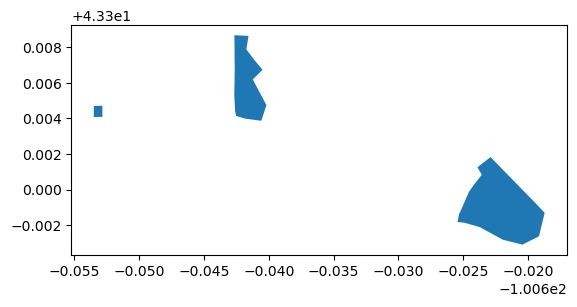

In [7]:
# Plot the campus boundary
sgu_boundary.plot()

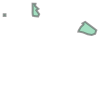

In [12]:
# Extract polygon geometry
sgu_polygon = sgu_boundary.geometry.iloc[0]
sgu_polygon

In [10]:
# Search for everthing tagged as 'building' within the specified boundary
sgu_buildings = osm.features_from_polygon(
    sgu_polygon,
    tags={"building": True}
)

sgu_buildings

nodes  \
element_type osmid                                                           
way          1329989373  [12305143261, 12305143262, 12305143263, 123051...   
             1329989674  [12305197578, 12305197579, 12305197580, 123051...   
             1329989763  [12305130161, 12305130162, 12305130163, 123051...   
             1329990142  [12305143566, 12305143567, 12305143568, 123051...   
             1329990226  [12305199459, 12305199460, 12305199461, 123051...   
             1329990342  [12305212760, 12305212761, 12305212762, 123052...   
             1329990737  [12305213705, 12305213706, 12305213707, 123052...   
             1329990805  [12305218542, 12305218543, 12305218544, 123052...   
             1329991082  [12305158057, 12305158058, 12305158059, 123051...   
             1329992072  [12305194356, 12305194357, 12305194358, 123051...   
             1329992618  [12305205162, 12305205163, 12305205164, 123052...   
             1329992860  [12305131765, 12305131766, 12305131767, 123051...   
             1329993273  [12305198654, 12305198655, 12305198656, 123051...   
             1329993577  [12305143576, 12305143577, 12305143578, 123051...   
             1329993817  [12305239602, 12305239603, 12305239604, 123052...   

                           building  \
element_type osmid                    
way          1329989373  university   
             1329989674  university   
             1329989763  university   
             1329990142  university   
             1329990226  university   
             1329990342  university   
             1329990737  university   
             1329990805  university   
             1329991082  university   
             1329992072  university   
             1329992618  university   
             1329992860  university   
             1329993273  university   
             1329993577  university   
             1329993817  university   

                                                                  geometry  \
element_type osmid                                                           
way          1329989373  POLYGON ((-100.62250 43.29803, -100.62206 43.2...   
             1329989674  POLYGON ((-100.62091 43.29774, -100.62090 43.2...   
             1329989763  POLYGON ((-100.61990 43.29795, -100.61967 43.2...   
             1329990142  POLYGON ((-100.61943 43.29870, -100.61948 43.2...   
             1329990226  POLYGON ((-100.62064 43.29949, -100.62064 43.2...   
             1329990342  POLYGON ((-100.62158 43.29887, -100.62160 43.2...   
             1329990737  POLYGON ((-100.62043 43.29875, -100.62053 43.2...   
             1329990805  POLYGON ((-100.62361 43.30024, -100.62345 43.3...   
             1329991082  POLYGON ((-100.62219 43.29901, -100.62286 43.2...   
             1329992072  POLYGON ((-100.64257 43.30818, -100.64257 43.3...   
             1329992618  POLYGON ((-100.64223 43.30744, -100.64232 43.3...   
             1329992860  POLYGON ((-100.64186 43.30503, -100.64148 43.3...   
             1329993273  POLYGON ((-100.64186 43.30551, -100.64187 43.3...   
             1329993577  POLYGON ((-100.64255 43.30525, -100.64254 43.3...   
             1329993817  POLYGON ((-100.64141 43.30488, -100.64141 43.3...   

                                                                      name  \
element_type osmid                                                           
way          1329989373        Sinte Gleska University Technology Building   
             1329989674           Sinte Gleska University Student Services   
             1329989763   Sinte Gleska University Mike Benge Student Union   
             1329990142    Sinte Gleska University Administration Building   
             1329990226         Sinte Gleska University Business Education   
             1329990342                             SGU Tiwahe Glu Kini Pi   
             1329990737        Sinte Gleska University Lakota Studies Tipi   
             1329990805            Sinte Gleska U

<Axes: >

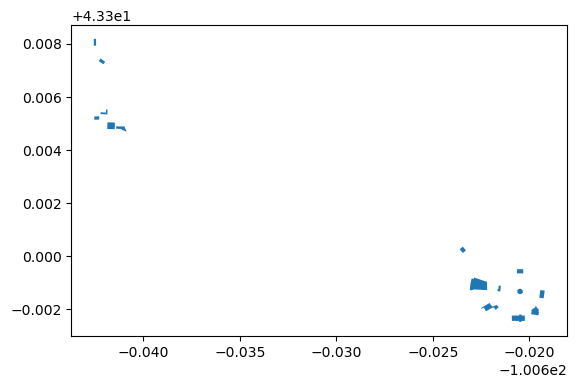

In [11]:
# Plot SGU buildings
sgu_buildings.plot()

In [ ]:
# Search for everthing tagged as 'water' within the specified distance of the boundary
campus_water = osm.features_from_address(
    "Sinte Gleska University, Mission, South Dakota, USA",
    tags={"natural":"water",
        "waterway": True,
        "water":True},
        dist=1000
)

campus_water

,,nodes,natural,source,geometry
element_type,osmid,,,,
way,263614031,"[2692370362, 2692370358, 2692370359, 269237035...",water,Bing 2012,"POLYGON ((-100.61049 43.29444, -100.61113 43.2..."


<Axes: >

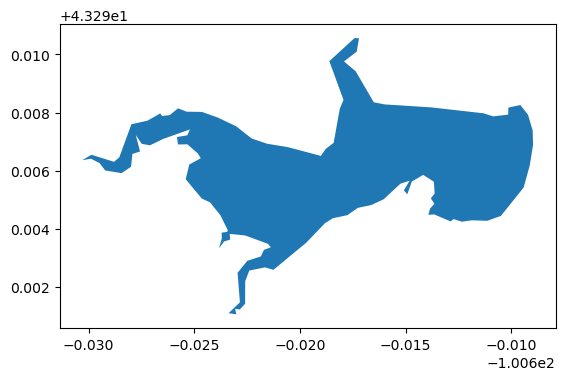

In [ ]:
# Plot the water that is nearby campus
campus_water.plot()

In [26]:
# Search for everthing tagged as 'water' within the specified distance of the boundary
campus_roads = osm.features_from_address(
    "Sinte Gleska University, Mission, South Dakota, USA",
    tags={"highway":True},
        dist=1000
)

campus_roads

crossing      highway  \
element_type osmid                              
node         9276355124   marked     crossing   
way          9923944         NaN  residential   
             9924103         NaN  residential   
             9924119         NaN  residential   
             9924208         NaN  residential   
             9924299         NaN  residential   
             9924301         NaN  residential   
             9924313         NaN  residential   
             9924388         NaN  residential   
             9924517         NaN  residential   
             9924706         NaN  residential   
             9924759         NaN  residential   
             9924876         NaN  residential   
             9924883         NaN  residential   
             9925007         NaN  residential   
             9925227         NaN  residential   
             9925279         NaN  residential   
             9925280         NaN  residential   
             9925284         NaN  residential   
             9925323         NaN  residential   
             9925384         NaN  residential   
             118976390       NaN      primary   
             221216383       NaN  residential   
             449824067       NaN  residential   
             449824072       NaN  residential   
             897904678       NaN      service   
             897904679       NaN      service   
             897904680       NaN      service   
             897904681       NaN      service   
             897904682       NaN      service   
             897904683       NaN      service   
             900654898       NaN      service   
             900654899       NaN      service   
             902539851       NaN      service   
             1005421229      NaN        track   
             1005421230      NaN  residential   
             1337083621      NaN  residential   
             1337295369      NaN  residential   
             1337295371      NaN  residential   

                                                                  geometry  \
element_type osmid                                                           
node         9276355124                        POINT (-100.62895 43.30308)   
way          9923944     LINESTRING (-100.63176 43.30149, -100.63262 43...   
             9924103     LINESTRING (-100.61297 43.29397, -100.61218 43...   
             9924119     LINESTRING (-100.62693 43.30100, -100.62756 43...   
             9924208     LINESTRING (-100.62711 43.29969, -100.62792 43...   
             9924299     LINESTRING (-100.62015 43.29908, -100.62007 43...   
             9924301     LINESTRING (-100.62204 43.30088, -100.62254 43...   
             9924313     LINESTRING (-100.62958 43.30060, -100.62980 43...   
             9924388     LINESTRING (-100.63045 43.30167, -100.63042 43...   
             9924517     LINESTRING (-100.62882 43.30457, -100.63000 43...   
             9924706     LINESTRING (-100.63048 43.30119, -100.63062 43...   
             9924759     LINESTRING (-100.62881 43.30308, -100.62881 43...   
             9924876     LINESTRING (-100.62204 43.30088, -100.62216 43...   
             9924883     LINESTRING (-100.62281 43.30307, -100.62280 43...   
             9925007     LINESTRING (-100.63689 43.30582, -100.63289 43...   
             9925227     LINESTRING (-100.63030 43.30456, -100.63029 43...   
             9925279     LINESTRING (-100.63048 43.30119, -100.63045 43...   
             9925280     LINESTRING (-100.63130 43.30060, -100.63086 43...   
             9925284     LINESTRING (-100.63262 43.30059, -100.63262 43...   
             9925323     LINESTRING (-100.62231 43.29827, -100.62276 43...   
             9925384     LINESTRING (-100.62958 43.30060, -100.63130 43...   
             118976390   LINESTRING (-100.64970 43.30572, -100.64922 43...   
             221216383   LINESTRING (-100.62881 43.30344, -100.63029 43...   
             449824067   LINESTRING (-100.62958 43.30060, -100.6

In [27]:
# Filter out linestring geometry from roads data for interactive plotting
road_lines = campus_roads[
    campus_roads.geometry.geom_type.isin(
        ["LineString", "MultiLineString"])]

road_lines


crossing      highway  \
element_type osmid                              
way          9923944         NaN  residential   
             9924103         NaN  residential   
             9924119         NaN  residential   
             9924208         NaN  residential   
             9924299         NaN  residential   
             9924301         NaN  residential   
             9924313         NaN  residential   
             9924388         NaN  residential   
             9924517         NaN  residential   
             9924706         NaN  residential   
             9924759         NaN  residential   
             9924876         NaN  residential   
             9924883         NaN  residential   
             9925007         NaN  residential   
             9925227         NaN  residential   
             9925279         NaN  residential   
             9925280         NaN  residential   
             9925284         NaN  residential   
             9925323         NaN  residential   
             9925384         NaN  residential   
             118976390       NaN      primary   
             221216383       NaN  residential   
             449824067       NaN  residential   
             449824072       NaN  residential   
             897904678       NaN      service   
             897904679       NaN      service   
             897904680       NaN      service   
             897904681       NaN      service   
             897904682       NaN      service   
             897904683       NaN      service   
             900654898       NaN      service   
             900654899       NaN      service   
             902539851       NaN      service   
             1005421229      NaN        track   
             1005421230      NaN  residential   
             1337083621      NaN  residential   
             1337295369      NaN  residential   
             1337295371      NaN  residential   

                                                                  geometry  \
element_type osmid                                                           
way          9923944     LINESTRING (-100.63176 43.30149, -100.63262 43...   
             9924103     LINESTRING (-100.61297 43.29397, -100.61218 43...   
             9924119     LINESTRING (-100.62693 43.30100, -100.62756 43...   
             9924208     LINESTRING (-100.62711 43.29969, -100.62792 43...   
             9924299     LINESTRING (-100.62015 43.29908, -100.62007 43...   
             9924301     LINESTRING (-100.62204 43.30088, -100.62254 43...   
             9924313     LINESTRING (-100.62958 43.30060, -100.62980 43...   
             9924388     LINESTRING (-100.63045 43.30167, -100.63042 43...   
             9924517     LINESTRING (-100.62882 43.30457, -100.63000 43...   
             9924706     LINESTRING (-100.63048 43.30119, -100.63062 43...   
             9924759     LINESTRING (-100.62881 43.30308, -100.62881 43...   
             9924876     LINESTRING (-100.62204 43.30088, -100.62216 43...   
             9924883     LINESTRING (-100.62281 43.30307, -100.62280 43...   
             9925007     LINESTRING (-100.63689 43.30582, -100.63289 43...   
             9925227     LINESTRING (-100.63030 43.30456, -100.63029 43...   
             9925279     LINESTRING (-100.63048 43.30119, -100.63045 43...   
             9925280     LINESTRING (-100.63130 43.30060, -100.63086 43...   
             9925284     LINESTRING (-100.63262 43.30059, -100.63262 43...   
             9925323     LINESTRING (-100.62231 43.29827, -100.62276 43...   
             9925384     LINESTRING (-100.62958 43.30060, -100.63130 43...   
             118976390   LINESTRING (-100.64970 43.30572, -100.64922 43...   
             221216383   LINESTRING (-100.62881 43.30344, -100.63029 43...   
             449824067   LINESTRING (-100.62958 43.30060, -100.62756 43...   
             449824072   LINESTRING (-100.61298 43.30722, -100.61303 43...   
             897904678   LINESTRING

<Axes: >

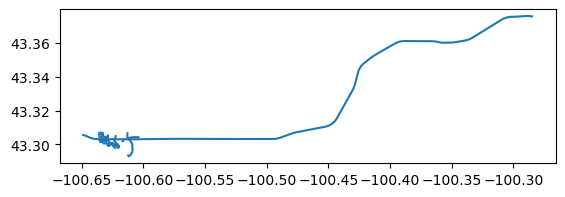

In [28]:
# Plot the road linestrings
road_lines.plot()